In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("influencers_cleaned.csv")
df.head()

,ranks,channel_info,influence_score,total_post,followers_clean,avg_likes_clean,60_eng_rate_clean,post_avg_like_clean,total_likes_clean,country
0,1,cristiano,92,3300,475800000,475800000,0.000139,6500000,29000000000,Spain
1,2,kyliejenner,91,6900,366200000,366200000,0.000162,5900000,57400000000,United States
2,3,leomessi,90,890,357300000,357300000,0.000124,4400000,6000000000,Unknown
3,4,selenagomez,93,1800,342700000,342700000,0.000097,3300000,11500000000,United States
4,5,therock,91,6800,334100000,334100000,0.00002,665300,12500000000,United States


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ranks                200 non-null    int64 
 1   channel_info         200 non-null    object
 2   influence_score      200 non-null    int64 
 3   total_post           200 non-null    int64 
 4   followers_clean      200 non-null    int64 
 5   avg_likes_clean      200 non-null    int64 
 6   60_eng_rate_clean    200 non-null    object
 7   post_avg_like_clean  200 non-null    object
 8   total_likes_clean    200 non-null    int64 
 9   country              200 non-null    object
dtypes: int64(6), object(4)
memory usage: 15.8+ KB


ranks                  0
channel_info           0
influence_score        0
total_post             0
followers_clean        0
avg_likes_clean        0
60_eng_rate_clean      0
post_avg_like_clean    0
total_likes_clean      0
country                0
dtype: int64

## Followers VS Engagement

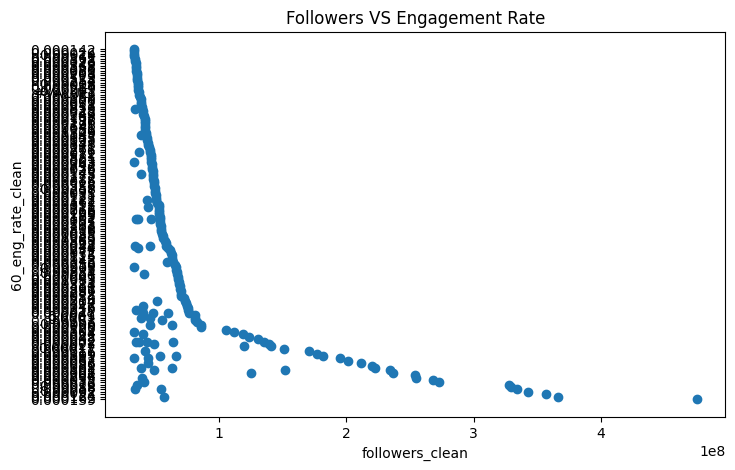

In [4]:
plt.figure(figsize = (8,5))
plt.scatter(df['followers_clean'],df['60_eng_rate_clean'])
plt.xlabel('followers_clean')
plt.ylabel('60_eng_rate_clean')
plt.title('Followers VS Engagement Rate')
plt.show()

## Influencer Score Distribution

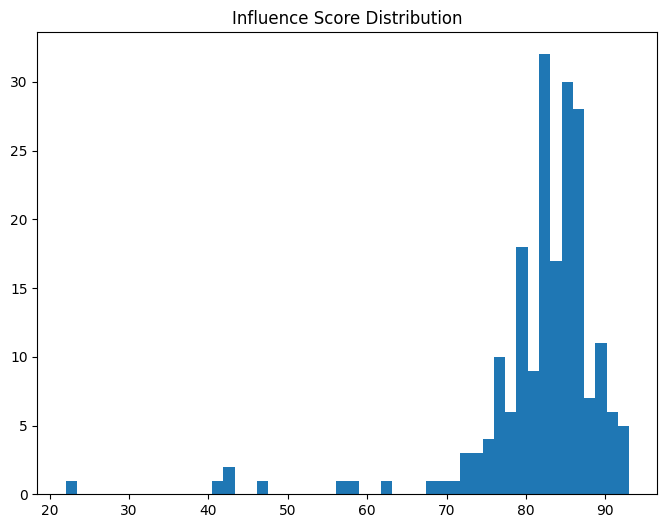

In [5]:
plt.figure(figsize=(8,6))
plt.hist(df['influence_score'],bins=50)
plt.title('Influence Score Distribution')
plt.show()

## Correlation Analysis

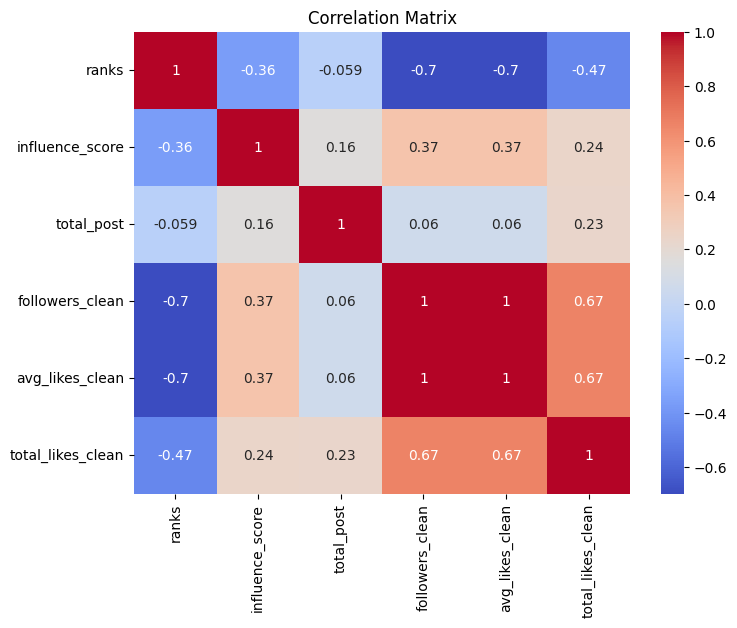

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

## Outlier Detection

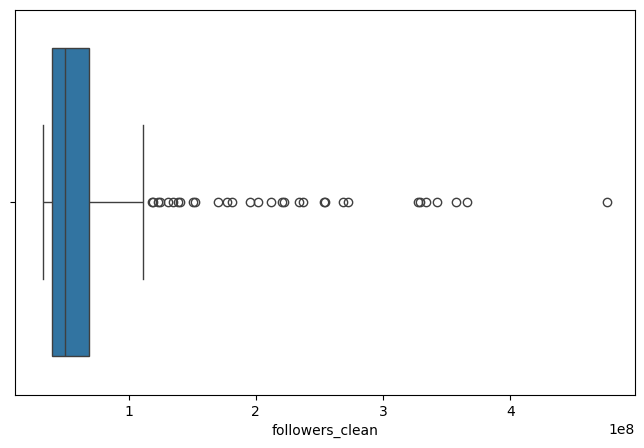

In [7]:
plt.figure(figsize = (8,5))
sns.boxplot(x=df['followers_clean'])
plt.show()

In [8]:
df.head(10)


,ranks,channel_info,influence_score,total_post,followers_clean,avg_likes_clean,60_eng_rate_clean,post_avg_like_clean,total_likes_clean,country
0,1,cristiano,92,3300,475800000,475800000,0.000139,6500000,29000000000,Spain
1,2,kyliejenner,91,6900,366200000,366200000,0.000162,5900000,57400000000,United States
2,3,leomessi,90,890,357300000,357300000,0.000124,4400000,6000000000,Unknown
3,4,selenagomez,93,1800,342700000,342700000,0.000097,3300000,11500000000,United States
4,5,therock,91,6800,334100000,334100000,0.00002,665300,12500000000,United States
5,6,kimkardashian,91,5600,329200000,329200000,0.000088,2900000,19900000000,United States
6,7,arianagrande,92,5000,327700000,327700000,0.00012,3900000,18400000000,United States
7,8,beyonce,92,2000,272800000,272800000,0.000076,2000000,7400000000,United States
8,9,khloekardashian,89,4100,268300000,268300000,0.000035,926900,9800000000,United States
9,10,justinbieber,91,7400,254500000,254500000,0.000059,1500000,13900000000,Canada


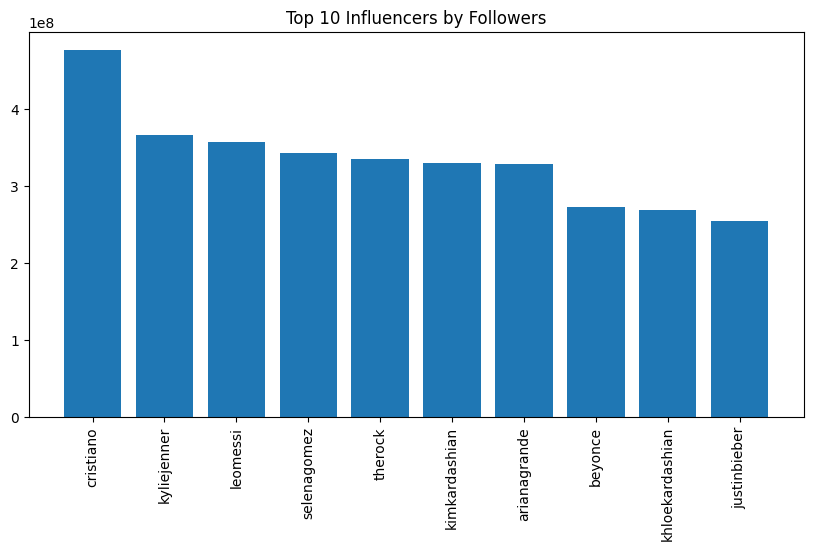

In [9]:
top10 = df.sort_values(by="followers_clean", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['channel_info'], top10['followers_clean'])
plt.xticks(rotation=90)
plt.title("Top 10 Influencers by Followers")
plt.show()

In [10]:
print("Key Insights:")
print("1. Followers and avg_likes are strongly correlated.")
print("2. Engagement rate is not strongly dependent on followers.")
print("3. Micro influencers often show higher engagement ratio.")

Key Insights:
1. Followers and avg_likes are strongly correlated.
2. Engagement rate is not strongly dependent on followers.
3. Micro influencers often show higher engagement ratio.


In [11]:
df_ml = df.copy()

In [12]:
df_ml.head()

,ranks,channel_info,influence_score,total_post,followers_clean,avg_likes_clean,60_eng_rate_clean,post_avg_like_clean,total_likes_clean,country
0,1,cristiano,92,3300,475800000,475800000,0.000139,6500000,29000000000,Spain
1,2,kyliejenner,91,6900,366200000,366200000,0.000162,5900000,57400000000,United States
2,3,leomessi,90,890,357300000,357300000,0.000124,4400000,6000000000,Unknown
3,4,selenagomez,93,1800,342700000,342700000,0.000097,3300000,11500000000,United States
4,5,therock,91,6800,334100000,334100000,0.00002,665300,12500000000,United States


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_percentage_error,mean_squared_error

In [17]:
df_ml = df.copy()
df_ml['like_ratio'] = df_ml['avg_likes_clean'] / df_ml['followers_clean']
df_ml.head()


,ranks,channel_info,influence_score,total_post,followers_clean,avg_likes_clean,60_eng_rate_clean,post_avg_like_clean,total_likes_clean,country,like_ratio
0,1,cristiano,92,3300,475800000,475800000,0.000139,6500000,29000000000,Spain,1.0
1,2,kyliejenner,91,6900,366200000,366200000,0.000162,5900000,57400000000,United States,1.0
2,3,leomessi,90,890,357300000,357300000,0.000124,4400000,6000000000,Unknown,1.0
3,4,selenagomez,93,1800,342700000,342700000,0.000097,3300000,11500000000,United States,1.0
4,5,therock,91,6800,334100000,334100000,0.00002,665300,12500000000,United States,1.0


## features(x) and target (y)

In [19]:
x = df_ml[["followers_clean","avg_likes_clean","total_post","influence_score","like_ratio"]]
y = df_ml['60_eng_rate_clean']

## Train Test Split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
  x,y,test_size = 0.2,random_state = 42
)

## Model

In [22]:
model = LinearRegression()
model.fit(x_train,y_train)

ValueError: could not convert string to float: '#VALUE!'

### kahi null value hai 

In [ ]:
# FINDING NULL VALUES
# df_ml.dtypes
# df_ml[df_ml == '#VALUE!']

# replace using nan(numpy)
df_ml.replace('#VALUE#',np.nan, inplace = True)
df_ml.isin(['#VALUE!']).sum()

ranks                  0
channel_info           0
influence_score        0
total_post             0
followers_clean        0
avg_likes_clean        0
60_eng_rate_clean      1
post_avg_like_clean    0
total_likes_clean      0
country                0
like_ratio             0
dtype: int64

### columns to numeric

In [35]:
cols = ["followers_clean","avg_likes_clean","total_post","influence_score","60_eng_rate_clean"]

for col in cols:
  df_ml[col] = pd.to_numeric(df_ml[col],errors='coerce')

### handel nan values

In [36]:
df_ml.fillna(df_ml.median(numeric_only=True),inplace=True)

### features recreate 

In [37]:
df_ml['like_ratio'] = df_ml["avg_likes_clean"]/(df_ml["followers_clean"]+1)

## Train Model

In [39]:
x = df_ml[['followers_clean','avg_likes_clean','total_post','influence_score','like_ratio']]
y = df_ml['60_eng_rate_clean']

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
  x,y,test_size = 0.2,random_state = 42
)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### prediction

In [40]:
y_pred = model.predict(x_test)

### model evaluation

In [43]:
print("r2_score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_percentage_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))

r2_score: 0.11582244479420578
MAE: 12.688096563911316
MSE: 5.600650253566741e-08


## Feature importance

In [47]:
coefficients  = pd.DataFrame({
  "Feature":x.columns,
  "coefficient":model.coef_
})
print(coefficients)

           Feature   coefficient
0  followers_clean -1.492367e-13
1  avg_likes_clean -1.492353e-13
2       total_post -3.061779e-08
3  influence_score -1.402850e-06
4       like_ratio -2.469869e-16


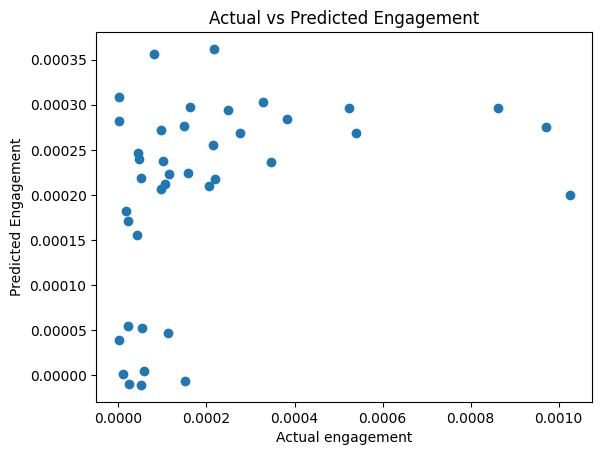

In [49]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.xlabel("Actual engagement")
plt.ylabel("Predicted Engagement")
plt.title("Actual vs Predicted Engagement")
plt.show()

In [50]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)
from sklearn.metrics import r2_score
print("Random Forest R2:", r2_score(y_test,rf_pred))

Random Forest R2: -0.023858913604759113


In [58]:
df_ml[['followers_clean',"60_eng_rate_clean"]].corr()

,followers_clean,60_eng_rate_clean
followers_clean,1.000000,-0.099957
60_eng_rate_clean,-0.099957,1.000000


In [56]:
df.sort_values(by="followers_clean").head(10)[['followers_clean','60_eng_rate_clean']]


,followers_clean,60_eng_rate_clean
199,32800000,0.00003
198,33000000,0.000142
195,33200000,0.00014
197,33200000,0.000026
196,33200000,0.000064
194,33300000,0.000063
192,33500000,0.000067
193,33500000,0.000161
191,33600000,0.000358
190,33700000,0.000023


In [55]:
df['country'].value_counts().head()

country
United States    66
Unknown          62
Brazil           13
India            12
Indonesia         7
Name: count, dtype: int64

## Insights
###### 1. There is no strong correlation between followers and engagement rate, indicating that a higher follower count does not guarantee better engagement.

###### 2. Engagement rates are consistently low across influencers, regardless of their follower size.

###### 3. The dataset shows very small engagement values, highlighting low audience interaction levels.

###### 4. Data preprocessing and cleaning were essential due to inconsistent and non-numeric values.

###### 5. Engagement rate is a more meaningful metric than follower count for brands when selecting influencers.